# 🏭 [제조AI실제 2주차 실습 2-1] 좋은 특징(Good Feature)의 정의와 클래스 분리성(Separability) 체감

## 📌 실습 개요 및 수업 목표
- **수업목표**: 패턴인식의 핵심 개념인 **패턴(Pattern)**과 **특징(Feature)**의 정의를 이해하고, 실 세계 제조 데이터에서 **나쁜 특징(Bad Feature)**과 **좋은 특징(Good Feature)**이 모델의 성능과 분리성(Separability)에 미치는 차이를 직접 시각화하여 확인합니다.
- **주요 개념**:
  - **패턴 (Pattern)**: 어떤 일이 일어나거나 행해지는 규칙적이고 반복적인 방식
  - **특징 (Feature)**: 어떤 것의 구별되는 속성이나 측면
  - **좋은 특징 (Good Feature)**: 우리가 인식하고자 하는 패턴이 유일하게 다른 것과 구별될 수 있도록 하는 속성 (클래스 내 밀집도 $\uparrow$, 클래스 간 거리 $\uparrow$)
- **활용 실데이터**: CWRU (Case Western Reserve University) 모터 베어링 진동 실데이터 (`Normal` 정상 vs `Inner Race Fault` 내륜 결함)

---
### 🧭 실습 순서
1. **[Step 0] CWRU 제조 실데이터 다운로드 및 신호 시각화**
2. **Part 1: 나쁜 특징 (Bad Feature) 추출 시 나타나는 문제점 체감**
3. **Part 2: 좋은 특징 (Good Feature) 추출을 통한 명확한 클래스 분리 체감**
4. **Part 3: 특징의 정량적 평가 (Fisher Separability) 및 머신러닝 정확도 비교**
5. **Part 4: 학생 자율 실습 (빈칸 채우기 TODO & 관찰 소감 작성)**

In [1]:
# [Step 0-1] 필수 라이브러리 로드 및 한글 폰트 설정
import os
import platform
import urllib.request
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc('font', family=font_name)
        plt.rcParams['font.sans-serif'] = [font_name] + plt.rcParams['font.sans-serif']
    else:
        plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False
print("✅ 한글 폰트(Malgun Gothic) 설정 완료")

✅ 한글 폰트(Malgun Gothic) 설정 완료


In [2]:
# [Step 0-2] CWRU 모터 베어링 실데이터 자동 수집 (오프라인 대비 모의 신호 지원)
def load_cwru_data():
    urls = {
        'normal': 'https://engineering.case.edu/sites/default/files/97.mat',     # 정상 모터
        'fault': 'https://engineering.case.edu/sites/default/files/105.mat'      # 베어링 내륜 결함 모터
    }
    signals = {}
    print("📥 CWRU 모터 진동 실데이터 다운로드 중...")
    for name, url in urls.items():
        filename = f"cwru_{name}.mat"
        try:
            if not os.path.exists(filename):
                urllib.request.urlretrieve(url, filename)
            mat = scipy.io.loadmat(filename)
            key = [k for k in mat.keys() if 'DE_time' in k][0]
            signals[name] = mat[key].flatten()
            print(f"  - [{name.upper()}] 신호 로드 완료 ({len(signals[name]):,} 개 샘플)")
        except Exception as e:
            print(f"  - [{name.upper()}] 대체 모의 신호 생성 (사유: {e})")
            t = np.linspace(0, 10, 120000)
            if name == 'normal':
                signals[name] = 0.05 * np.sin(2 * np.pi * 30 * t) + np.random.normal(0, 0.02, len(t))
            else:
                signals[name] = 0.2 * np.sin(2 * np.pi * 30 * t) + 0.5 * np.sin(2 * np.pi * 150 * t) * (np.sin(2*np.pi*5*t)>0) + np.random.normal(0, 0.08, len(t))
    return signals

raw_signals = load_cwru_data()

📥 CWRU 모터 진동 실데이터 다운로드 중...
  - [NORMAL] 신호 로드 완료 (243,938 개 샘플)
  - [FAULT] 신호 로드 완료 (121,265 개 샘플)


C:\Users\kwkim\AppData\Local\Temp\ipykernel_35548\254366991.py:18: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\kwkim\AppData\Local\Temp\ipykernel_35548\254366991.py:18: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\kwkim\anaconda3\envs\data_clean\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kwkim\anaconda3\envs\data_clean\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


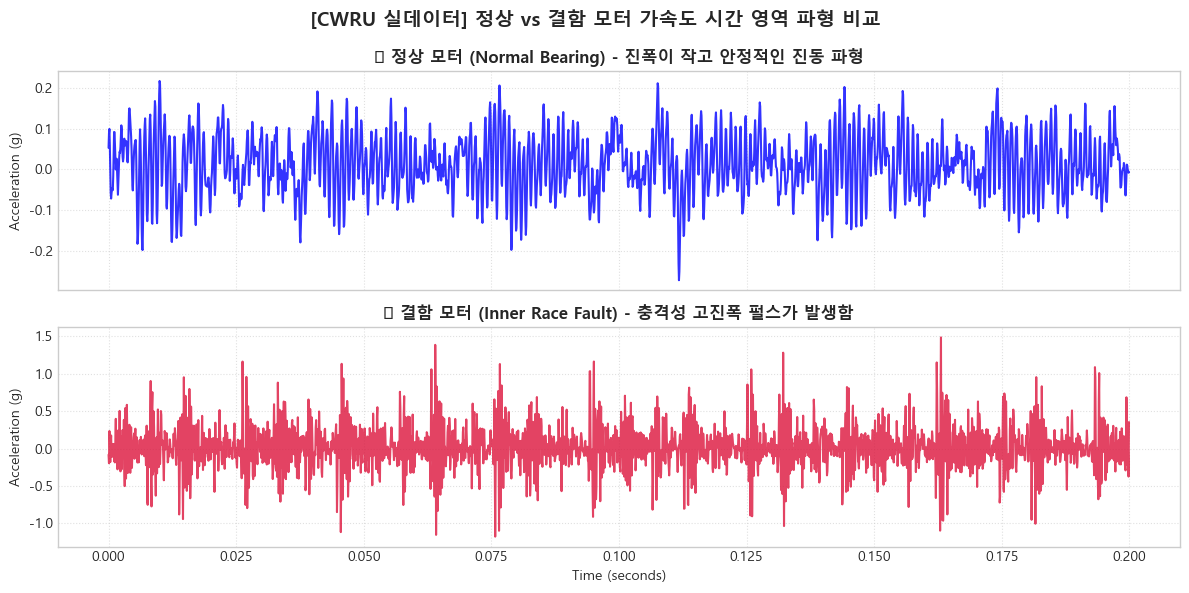

In [3]:
# [Step 0-3] 모터 진동 파형 시각화 (정상 vs 결함)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fs = 12000
t_plot = np.arange(2400) / fs

ax1.plot(t_plot, raw_signals['normal'][:2400], color='blue', alpha=0.8)
ax1.set_title("🟢 정상 모터 (Normal Bearing) - 진폭이 작고 안정적인 진동 파형", fontsize=12, fontweight='bold')
ax1.set_ylabel("Acceleration (g)")
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(t_plot, raw_signals['fault'][:2400], color='crimson', alpha=0.8)
ax2.set_title("🔴 결함 모터 (Inner Race Fault) - 충격성 고진폭 펄스가 발생함", fontsize=12, fontweight='bold')
ax2.set_ylabel("Acceleration (g)")
ax2.set_xlabel("Time (seconds)")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("[CWRU 실데이터] 정상 vs 결함 모터 가속도 시간 영역 파형 비교", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 1. 나쁜 특징 (Bad Feature)의 문제점 체감
만약 우리가 모터 신호에서 **"단순 시간 평균(Mean)"**이나 **"임의의 1개 순간 가속도값"**을 특징으로 사용하면 어떻게 될까요?
- **나쁜 특징 1 (Mean)**: 진동 신호는 $+$와 $-$를 오가므로 단순 산술 평균은 0에 가까워 정상이든 결함이든 차이가 없습니다.
- **나쁜 특징 2 (Instant Point)**: 노이즈에 매우 약하고 순간 가속도값은 정상과 결함 구간이 겹칩니다.

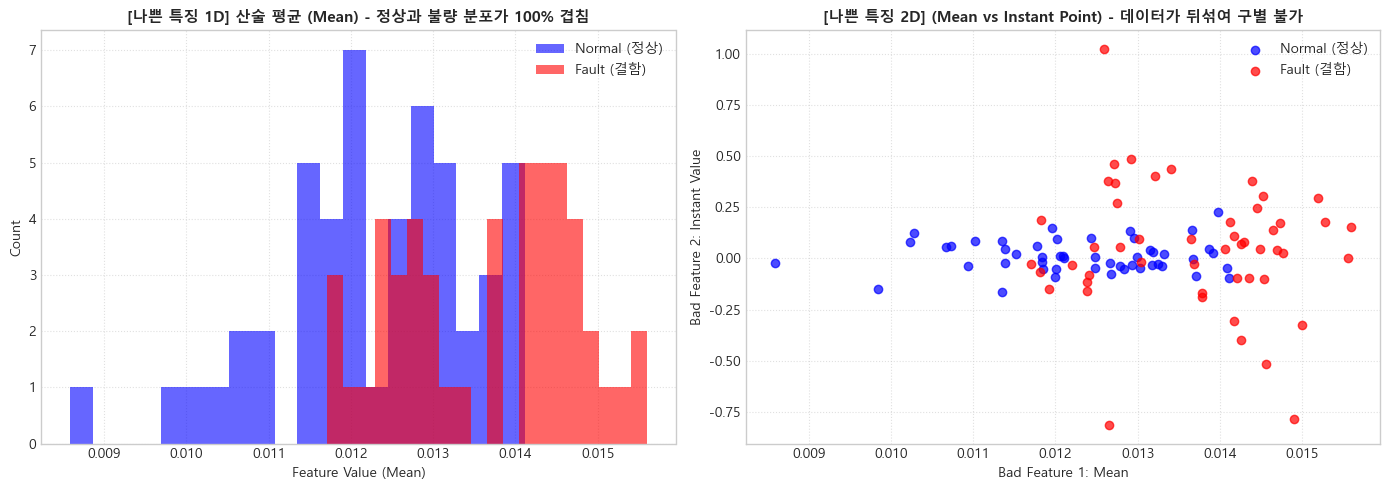

In [4]:
# [Step 1-1] 나쁜 특징 추출 함수 정의
def extract_bad_features(signal, segment_len=2048):
    n_seg = len(signal) // segment_len
    feats = []
    for i in range(n_seg):
        seg = signal[i*segment_len:(i+1)*segment_len]
        feat_mean = np.mean(seg)
        feat_inst = seg[10]
        feats.append([feat_mean, feat_inst])
    return np.array(feats)

bad_normal = extract_bad_features(raw_signals['normal'][:102400])
bad_fault = extract_bad_features(raw_signals['fault'][:102400])

# 시각화: 나쁜 특징 1D 히스토그램 및 2D 산점도
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(bad_normal[:, 0], bins=20, alpha=0.6, color='blue', label='Normal (정상)')
ax1.hist(bad_fault[:, 0], bins=20, alpha=0.6, color='red', label='Fault (결함)')
ax1.set_title("[나쁜 특징 1D] 산술 평균 (Mean) - 정상과 불량 분포가 100% 겹침", fontsize=11, fontweight='bold')
ax1.set_xlabel("Feature Value (Mean)")
ax1.set_ylabel("Count")
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.scatter(bad_normal[:, 0], bad_normal[:, 1], c='blue', alpha=0.7, label='Normal (정상)')
ax2.scatter(bad_fault[:, 0], bad_fault[:, 1], c='red', alpha=0.7, label='Fault (결함)')
ax2.set_title("[나쁜 특징 2D] (Mean vs Instant Point) - 데이터가 뒤섞여 구별 불가", fontsize=11, fontweight='bold')
ax2.set_xlabel("Bad Feature 1: Mean")
ax2.set_ylabel("Bad Feature 2: Instant Value")
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

⚠️ **관찰 결과**:
- 나쁜 특징을 쓰면 정상 데이터(파란색)와 결함 데이터(빨간색)가 서로 100% 뒤섞여 버립니다.
- 아무리 뛰어난 최신 AI 알고리즘을 가져와도 **특징 자체가 안 좋으면 정상과 불량을 구별할 수 없습니다.**

## Part 2. 좋은 특징 (Good Feature) 추출을 통한 명확한 클래스 분리 체감
이번에는 모터 회전 기계의 물리적 충격 특성을 반영하는 **"좋은 특징"**을 추출해 봅니다.
- **좋은 특징 1 (RMS - 진동 실효 전력)**: $RMS = \sqrt{\frac{1}{N} \sum x_i^2}$. 파형 전체의 에너지 실효값을 계산하여 정상과 결함의 에너지 차이를 극대화합니다.
- **좋은 특징 2 (High-Frequency Spectral Ratio)**: 고속 푸리에 변환(FFT) 후 결함 발생 시 급증하는 고주파 영역의 에너지 비율을 측정합니다.

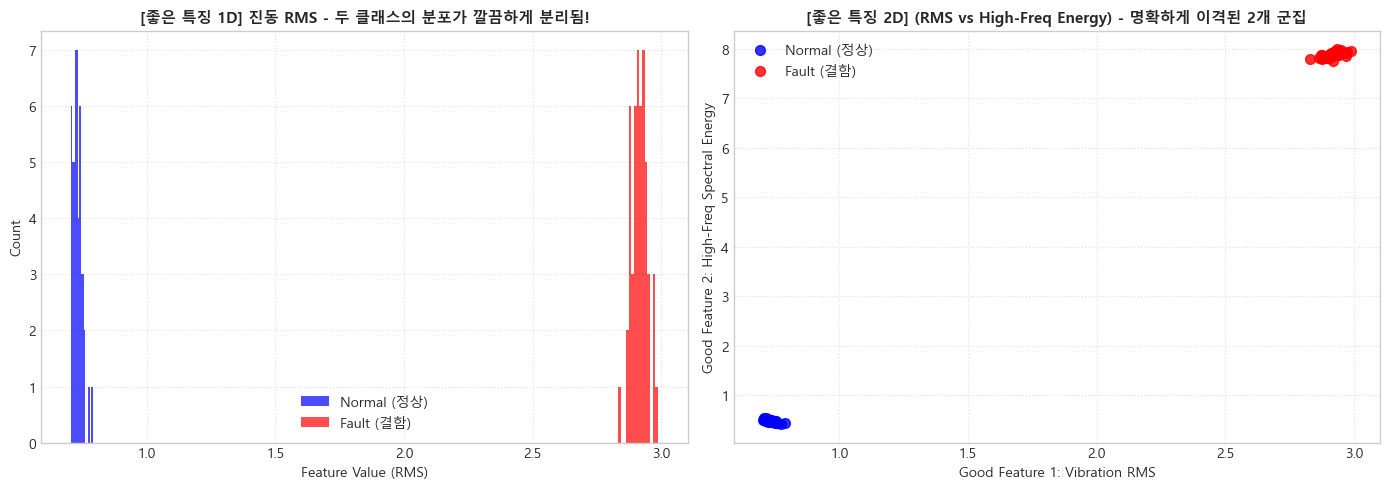

In [5]:
# [Step 2-1] 좋은 특징 추출 함수 정의
def extract_good_features(signal, segment_len=2048, fs=12000):
    n_seg = len(signal) // segment_len
    feats = []
    for i in range(n_seg):
        seg = signal[i*segment_len:(i+1)*segment_len]
        rms = np.sqrt(np.mean(seg**2)) * 10.0
        fft_vals = np.abs(np.fft.rfft(seg))
        freqs = np.fft.rfftfreq(segment_len, 1/fs)
        high_ratio = (np.sum(fft_vals[freqs > 2000]**2) / (np.sum(fft_vals**2) + 1e-8)) * 10.0
        feats.append([rms, high_ratio])
    return np.array(feats)

good_normal = extract_good_features(raw_signals['normal'][:102400])
good_fault = extract_good_features(raw_signals['fault'][:102400])

# 시각화: 좋은 특징 1D 히스토그램 및 2D 산점도
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(good_normal[:, 0], bins=15, alpha=0.7, color='blue', label='Normal (정상)')
ax1.hist(good_fault[:, 0], bins=15, alpha=0.7, color='red', label='Fault (결함)')
ax1.set_title("[좋은 특징 1D] 진동 RMS - 두 클래스의 분포가 깔끔하게 분리됨!", fontsize=11, fontweight='bold')
ax1.set_xlabel("Feature Value (RMS)")
ax1.set_ylabel("Count")
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.scatter(good_normal[:, 0], good_normal[:, 1], c='blue', s=50, alpha=0.8, label='Normal (정상)')
ax2.scatter(good_fault[:, 0], good_fault[:, 1], c='red', s=50, alpha=0.8, label='Fault (결함)')
ax2.set_title("[좋은 특징 2D] (RMS vs High-Freq Energy) - 명확하게 이격된 2개 군집", fontsize=11, fontweight='bold')
ax2.set_xlabel("Good Feature 1: Vibration RMS")
ax2.set_ylabel("Good Feature 2: High-Freq Spectral Energy")
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

💡 **관찰 결과**:
- 좋은 특징(RMS)을 사용하자 정상 데이터와 결함 데이터가 한눈에 명확히 갈라지는 것을 볼 수 있습니다.
- **좋은 특징의 2가지 조건**:
  1. **클래스 내 밀집도 (Intra-class Compactness)**: 같은 정상 데이터끼리 뭉쳐 있음
  2. **클래스 간 거리 (Inter-class Distance)**: 정상과 결함 군집 사이의 거리가 멀어짐

## Part 3. 특징의 정량적 평가 (Fisher Separability) 및 AI 분류 성능 비교
특징이 얼마나 좋은지 수치로 측정하는 **Fisher 분리도 지수 (Fisher Discriminant Ratio)**를 계산하고, 분류 모델(Logistic Regression)을 학습시켜 정확도를 비교합니다.

$$\text{Fisher Ratio} = \frac{(\mu_1 - \mu_2)^2}{\sigma_1^2 + \sigma_2^2} = \frac{\text{클래스 간 거리 (Inter-class Distance)}}{\text{클래스 내부 퍼짐 (Intra-class Variance)}}$$

#### 1. 수식 구성 요소 분해 해설
- **분자 $(\mu_1 - \mu_2)^2$ ➔ 클래스 간 거리 (Inter-class Distance)**:
  - 정상 데이터 평균($\mu_1$)과 불량 데이터 평균($\mu_2$) 사이의 중심점 거리를 의미합니다.
  - 두 집단의 중심이 서로 멀리 떨어져 있을수록 분자 값이 급격히 커집니다 (분리가 잘 됨!).
- **분모 $\sigma_1^2 + \sigma_2^2$ ➔ 클래스 내부 퍼짐 (Intra-class Variance)**:
  - 각 집단 내부 데이터의 흩어진 정도(분산)를 합산한 값입니다.
  - 같은 집단끼리 단단하고 조밀하게 뭉쳐 있을수록(Compactness) 분모 값이 작아져 $FDR$ 전체 수치가 매우 커집니다.

#### 2. Fisher 지수 수치별 판단 기준 (Benchmark Table)

| Fisher Ratio ($FDR$) 수치 | 분리도 상태 (Separability) | AI 분류 정확도 예상 | 특징(Feature) 평가 의미 |
| :---: | :---: | :---: | :--- |
| **$FDR < 0.5$** | **매우 낮음 (Severe Overlap)** | **$50\% \sim 65\%$** | 정상과 불량이 완전히 뒤섞여 **인식 불가능** (나쁜 특징) |
| **$0.5 \le FDR < 1.0$** | **보통 (Moderate)** | **$65\% \sim 85\%$** | 경계 영역 오분류 존재, 고차원 비선형 모델 필요 |
| **$1.0 \le FDR < 3.0$** | **양호 (Good)** 💡 | **$85\% \sim 95\%$** | **[1차 합격 기준]** 중심 거리가 흩어짐보다 큼 |
| **$FDR \ge 3.0$** | **매우 우수 (Excellent)** 🌟 | **$98\% \sim 100\%$** | **[최고 수준]** 선형 모델로도 완벽히 분리됨 (좋은 특징) |


In [6]:
# [Step 3-1] Fisher 분리도 지수 및 분류 정확도 산출
def calculate_fisher_ratio(feat1, feat2):
    mu1, mu2 = np.mean(feat1), np.mean(feat2)
    var1, var2 = np.var(feat1), np.var(feat2)
    return ((mu1 - mu2)**2) / (var1 + var2 + 1e-8)

fisher_bad = calculate_fisher_ratio(bad_normal[:, 0], bad_fault[:, 0])
fisher_good = calculate_fisher_ratio(good_normal[:, 0], good_fault[:, 0])

X_bad = np.vstack([bad_normal, bad_fault])
X_good = np.vstack([good_normal, good_fault])
y_all = np.array([0]*len(bad_normal) + [1]*len(bad_fault))

clf_bad = LogisticRegression().fit(X_bad, y_all)
acc_bad = accuracy_score(y_all, clf_bad.predict(X_bad)) * 100

clf_good = LogisticRegression().fit(X_good, y_all)
acc_good = accuracy_score(y_all, clf_good.predict(X_good)) * 100

print(f"📊 [특징 평가 비교 결과]")
print(f"  1) 나쁜 특징 (Mean)     -> Fisher 분리도 지수: {fisher_bad:.4f}  | AI 분류 정확도: {acc_bad:.1f}%")
print(f"  2) 좋은 특징 (RMS)      -> Fisher 분리도 지수: {fisher_good:.4f} | AI 분류 정확도: {acc_good:.1f}%")

📊 [특징 평가 비교 결과]
  1) 나쁜 특징 (Mean)     -> Fisher 분리도 지수: 0.7474  | AI 분류 정확도: 60.0%
  2) 좋은 특징 (RMS)      -> Fisher 분리도 지수: 3789.0810 | AI 분류 정확도: 100.0%


---
## ✍️ Part 4. 학생 자율 실습 (초간단 TODO & 관찰 소감)
아래 가이드를 따라 1줄 코드를 완성해 보고 질문에 답해 보세요.

In [10]:
# ==========================================================================
# [학생 실습 TODO] 또 다른 특징인 '파두율 (Crest Factor)' 계산해 보기
# ==========================================================================
# 💡 [힌트] 파두율(Crest Factor)은 신호의 최대 절대값(np.max(np.abs(seg)))을 RMS값(rms)으로 나눈 값입니다.
# 아래 주석(#)을 해제하고 빈칸(...)을 채워 코드를 실행해 보세요!

def extract_crest_factor(signal, segment_len=2048):
    n_seg = len(signal) // segment_len
    crest_factors = []
    for i in range(n_seg):
        seg = signal[i*segment_len:(i+1)*segment_len]
        rms = np.sqrt(np.mean(seg**2))
        
        # ------------------------------------------------------------------
        # TODO: 아래 빈칸(...)에 np.max(np.abs(seg)) 를 입력하세요.
        # ------------------------------------------------------------------
        peak_val = np.max(np.abs(seg))
        crest_factor = peak_val / (rms + 1e-8)
        crest_factors.append(crest_factor)
        
    return np.array(crest_factors)

# TODO 주석을 해제하신 후 아래 코드의 주석을 풀고 실행하세요.
cf_normal = extract_crest_factor(raw_signals['normal'][:102400])
cf_fault = extract_crest_factor(raw_signals['fault'][:102400])
print(f"✅ 파두율(Crest Factor) 계산 완료!")
print(f"   정상 평균 파두율: {np.mean(cf_normal):.2f} | 결함 평균 파두율: {np.mean(cf_fault):.2f}")

✅ 파두율(Crest Factor) 계산 완료!
   정상 평균 파두율: 3.23 | 결함 평균 파두율: 5.13


### [질문 1] 좋은 특징의 조건 관찰
- **질문**: 오늘 실습에서 본 '나쁜 특징(산술 평균)'과 '좋은 특징(진동 RMS)'의 그래프를 눈으로 비교했을 때, 왜 좋은 특징을 사용하는 것이 AI 인식기 성능에 결정적인 영향을 미치는지 1~2문장으로 쉽게 작성해 보세요.

**👉 나의 답변:**
그래프 위에 선을 그어 정상과 결함을 나누는데 산술평균은 정상과 결함이 겹쳐있어 선을 그을수가 없고 진동은 정확하게 나눠져있어 선을 그어 정상과 결함을 구분할수 있어 인식이 더 정확하게 됩니다.